# 03 — Feature: TypeName
Engineers numeric features from the `TypeName` column using one-hot encoding.

**Output features:** `Type_Gaming`, `Type_Netbook`, `Type_Notebook`, `Type_Ultrabook`, `Type_Workstation`, `Type_2 in 1 Convertible`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ld = pd.read_csv("laptop_data_features.csv")
print(f"Shape: {ld.shape}")

Shape: (1303, 11)


In [3]:
# Explore TypeName
print(ld['TypeName'].value_counts())
print(f"\nUnique types: {ld['TypeName'].nunique()}")

TypeName
Notebook              727
Gaming                205
Ultrabook             196
2 in 1 Convertible    121
Workstation            29
Netbook                25
Name: count, dtype: int64

Unique types: 6


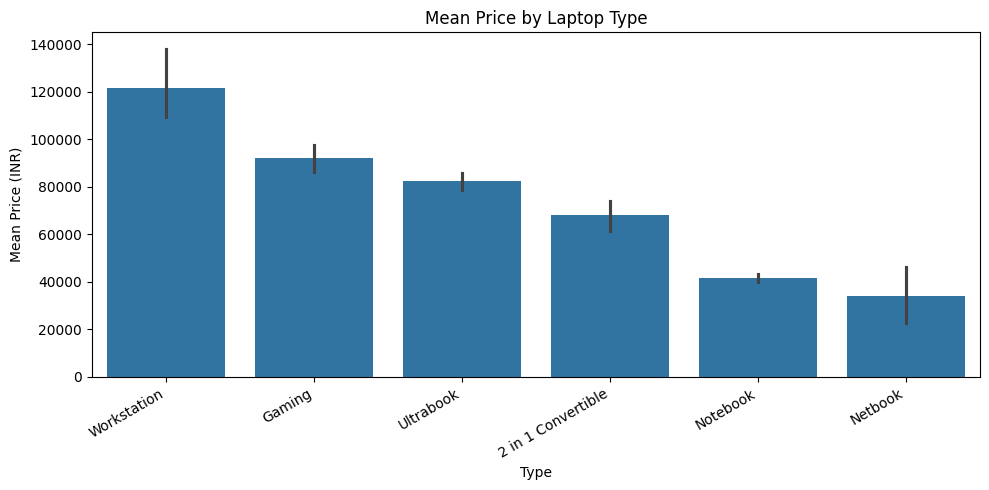

In [4]:
# Mean price by type (barplot)
plt.figure(figsize=(10, 5))
sns.barplot(data=ld, x='TypeName', y='Price', estimator='mean', order=ld.groupby('TypeName')['Price'].mean().sort_values(ascending=False).index)
plt.title("Mean Price by Laptop Type")
plt.xlabel("Type")
plt.ylabel("Mean Price (INR)")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [5]:
# One-hot encode TypeName
type_dummies = pd.get_dummies(ld['TypeName'], prefix='Type')
ld = pd.concat([ld, type_dummies], axis=1)

type_cols = [c for c in ld.columns if c.startswith('Type_')]
print("Columns added:", type_cols)
print(ld[type_cols].sum())   # count per type

Columns added: ['Type_2 in 1 Convertible', 'Type_Gaming', 'Type_Netbook', 'Type_Notebook', 'Type_Ultrabook', 'Type_Workstation']
Type_2 in 1 Convertible    121
Type_Gaming                205
Type_Netbook                25
Type_Notebook              727
Type_Ultrabook             196
Type_Workstation            29
dtype: int64


In [6]:
# Correlation with Price
print("Correlation with Price:")
print(ld[type_cols + ['Price']].corr()['Price'].sort_values(ascending=False))

Correlation with Price:
Price                      1.000000
Type_Gaming                0.375789
Type_Ultrabook             0.255658
Type_Workstation           0.249752
Type_2 in 1 Convertible    0.072675
Type_Netbook              -0.097572
Type_Notebook             -0.549248
Name: Price, dtype: float64


In [7]:
# Drop raw column
ld.drop(columns=['TypeName'], inplace=True)

In [8]:
ld.to_csv("laptop_data_features.csv", index=False)
print("Saved: laptop_data_features.csv")
print(f"Shape: {ld.shape}")
print(f"Columns: {list(ld.columns)}")

Saved: laptop_data_features.csv
Shape: (1303, 16)
Columns: ['Inches', 'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price', 'Company_TE', 'Type_2 in 1 Convertible', 'Type_Gaming', 'Type_Netbook', 'Type_Notebook', 'Type_Ultrabook', 'Type_Workstation']
